In [15]:
import pandas as pd

# Load Dataset
df = pd.read_csv("UnifiedDataset.csv")

print(df.head())
print(df.shape)

       Country  Year      Gender  Life Expectancy  Infant Mortality Rate  \
0  Afghanistan  1990  Both sexes           50.331                  120.4   
1  Afghanistan  1990      Female           51.442                  114.2   
2  Afghanistan  1990        Male           49.281                  126.2   
3  Afghanistan  1991  Both sexes           50.999                  116.8   
4  Afghanistan  1991      Female           52.119                  110.7   

   Low CI Value Infant Mortality Rate  High CI Value Infant Mortality Rate  \
0                               111.2                                130.9   
1                               105.1                                124.7   
2                               116.4                                137.5   
3                               108.2                                126.2   
4                               102.1                                120.4   

   Under 5 Mortality Rate  Low CI Value Under 5 Mortality Rate  \
0       

In [14]:
from google.colab import files
uploaded = files.upload()

Saving UnifiedDataset.csv to UnifiedDataset.csv


In [16]:
import pandas as pd

df = pd.read_csv("UnifiedDataset.csv")

print(df.head())

       Country  Year      Gender  Life Expectancy  Infant Mortality Rate  \
0  Afghanistan  1990  Both sexes           50.331                  120.4   
1  Afghanistan  1990      Female           51.442                  114.2   
2  Afghanistan  1990        Male           49.281                  126.2   
3  Afghanistan  1991  Both sexes           50.999                  116.8   
4  Afghanistan  1991      Female           52.119                  110.7   

   Low CI Value Infant Mortality Rate  High CI Value Infant Mortality Rate  \
0                               111.2                                130.9   
1                               105.1                                124.7   
2                               116.4                                137.5   
3                               108.2                                126.2   
4                               102.1                                120.4   

   Under 5 Mortality Rate  Low CI Value Under 5 Mortality Rate  \
0       

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22050 entries, 0 to 22049
Columns: 150 entries, Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 25.2+ MB


In [18]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
countries = ['India','Pakistan','Bangladesh','Nepal','Bhutan','Sri Lanka','China','Afghanistan','Myanmar']
filtered_df = df[df['Country'].isin(countries)]

In [21]:
filtered_df.groupby('Country')['Life Expectancy'].mean().sort_values()

,Life Expectancy
Country,
Afghanistan,58.085733
Myanmar,61.763678
Bhutan,63.723000
Pakistan,63.897778
Nepal,64.087978
India,64.253967
Bangladesh,66.850122
China,72.885900
Sri Lanka,73.330411


In [22]:
filtered_df.groupby('Country')['Infant Mortality Rate'].mean()

,Infant Mortality Rate
Country,
Afghanistan,79.493111
Bangladesh,55.201000
Bhutan,49.495889
China,23.095111
India,57.346333
Myanmar,57.808000
Nepal,52.767333
Pakistan,79.015222
Sri Lanka,12.495667


In [23]:
filtered_df[['Life Expectancy','Infant Mortality Rate']].corr()

,Life Expectancy,Infant Mortality Rate
Life Expectancy,1.000000,-0.910213
Infant Mortality Rate,-0.910213,1.000000


In [24]:
filtered_df.groupby('Year')['Life Expectancy'].mean()

,Life Expectancy
Year,
1990,58.842074
1991,59.317407
1992,59.785778
1993,60.244963
1994,60.697037
1995,61.149704
1996,61.613407
1997,62.095519
1998,62.598185


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

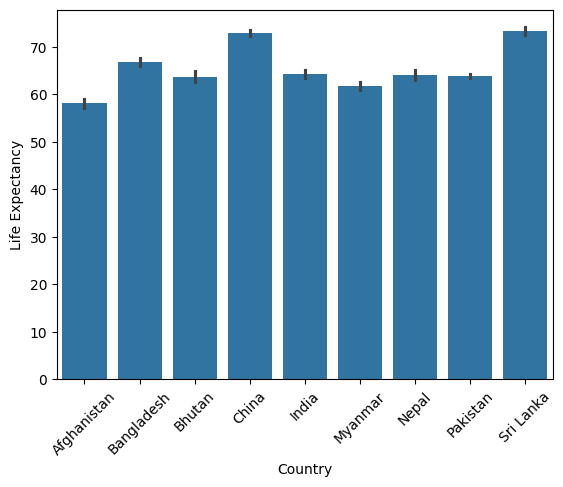

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Country', y='Life Expectancy', data=filtered_df)
plt.xticks(rotation=45)
plt.show()

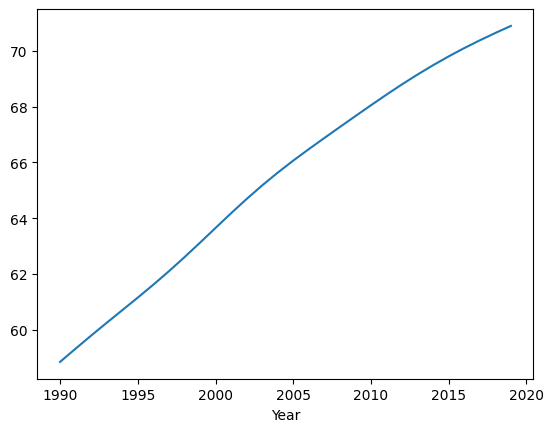

In [27]:
filtered_df.groupby('Year')['Life Expectancy'].mean().plot()
plt.show()

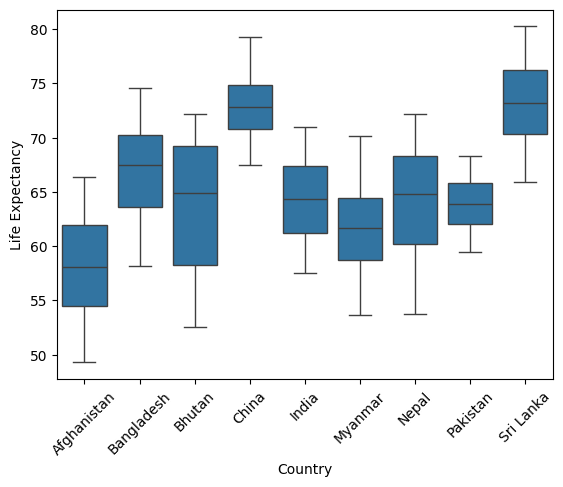

In [28]:
sns.boxplot(x='Country', y='Life Expectancy', data=filtered_df)
plt.xticks(rotation=45)
plt.show()

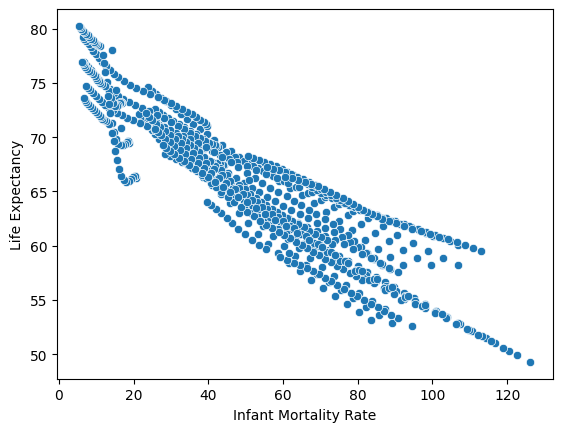

In [29]:
sns.scatterplot(
    x='Infant Mortality Rate',
    y='Life Expectancy',
    data=filtered_df
)
plt.show()

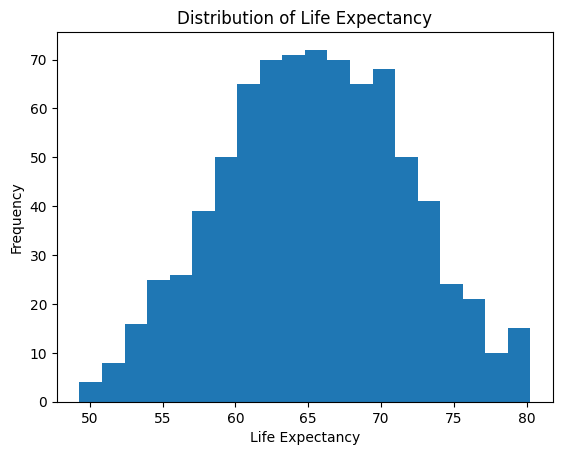

In [30]:
plt.hist(filtered_df['Life Expectancy'], bins=20)
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.title('Distribution of Life Expectancy')
plt.show()

# Machine Learning Model Comparison
Predict life expectancy using available health-related factors.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Using filtered_df which contains 810 rows of data for the target countries
df_ml = filtered_df.dropna(subset=["Life Expectancy"])

# Selecting numeric columns for X, excluding the target and Year
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()
features = [col for col in numeric_cols if col not in ["Life Expectancy", "Year"]]

X = df_ml[features]
y = df_ml["Life Expectancy"]

# Handle missing values in features by filling with mean
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Samples available: {len(df_ml)}")
print(f"Using features: {features[:5]}... (Total: {len(features)})")

Samples available: 810
Using features: ['Infant Mortality Rate', 'Low CI Value Infant Mortality Rate', 'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate', 'Low CI Value Under 5 Mortality Rate']... (Total: 146)


### 1. Linear Regression

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

### 2. Decision Tree Regressor

In [33]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

### 3. Random Forest Regressor

In [34]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

### Model Evaluation & Comparison

In [35]:
results = []

for name, pred in [("Linear Regression", lr_pred), ("Decision Tree", dt_pred), ("Random Forest", rf_pred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.643161,0.987016,0.974765
1,Decision Tree,0.694340,1.217529,0.961602
2,Random Forest,0.569407,0.864951,0.980621


# Confusion Matrix for Classification
To generate a confusion matrix, we categorize Life Expectancy into risk levels:
- **Low Risk**: > 70 years
- **Medium Risk**: 60 - 70 years
- **High Risk**: < 60 years

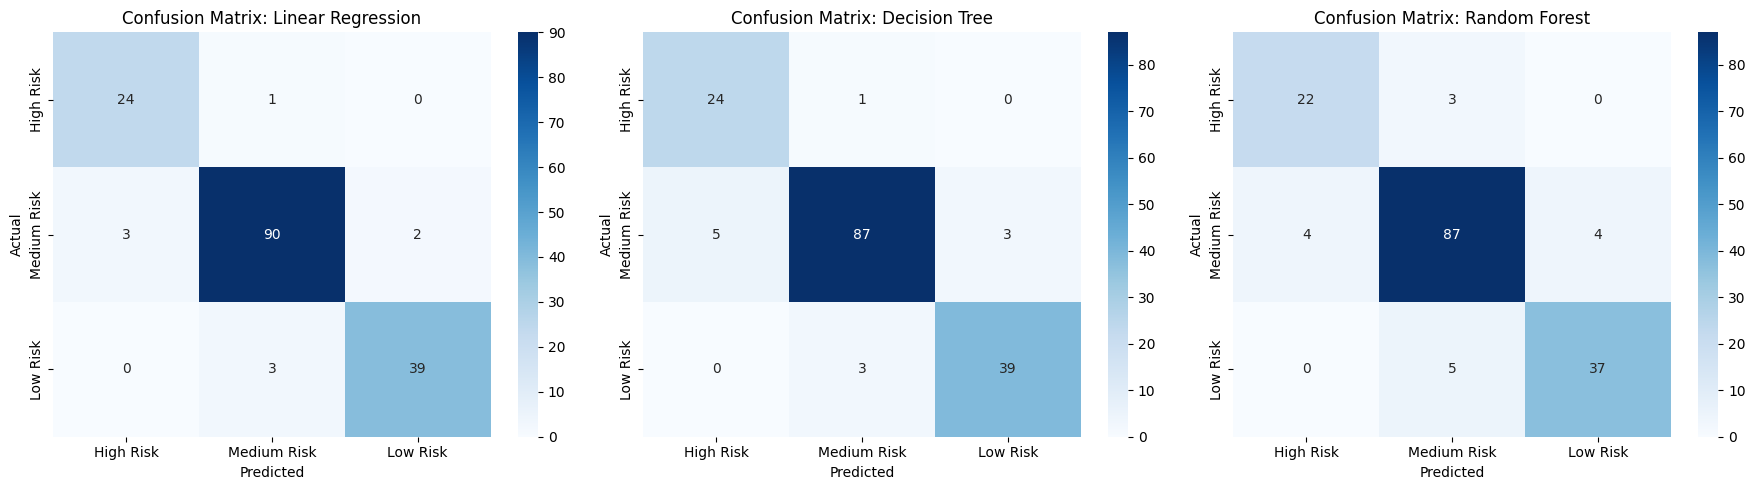

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def categorize_risk(val):
    if val > 70:
        return 'Low Risk'
    elif val >= 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Convert actual and predicted values to categories
risk_labels = ['High Risk', 'Medium Risk', 'Low Risk']
y_test_cat = [categorize_risk(v) for v in y_test]

# Plotting function
def plot_cm(y_true, y_pred_cont, title):
    y_pred_cat = [categorize_risk(v) for v in y_pred_cont]
    cm = confusion_matrix(y_true, y_pred_cat, labels=risk_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=risk_labels, yticklabels=risk_labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

# Create subplots for all 3 models
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_cm(y_test_cat, lr_pred, 'Linear Regression')

plt.subplot(1, 3, 2)
plot_cm(y_test_cat, dt_pred, 'Decision Tree')

plt.subplot(1, 3, 3)
plot_cm(y_test_cat, rf_pred, 'Random Forest')

plt.tight_layout()
plt.show()

### Visualizing Risk Categories
Let's visualize the distribution of Life Expectancy within the categorized risk levels.

/tmp/ipykernel_777/1211538642.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk Category', y='Life Expectancy', data=df_ml, order=['High Risk', 'Medium Risk', 'Low Risk'], palette='Set2')
/tmp/ipykernel_777/1211538642.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk Category', data=df_ml, order=['High Risk', 'Medium Risk', 'Low Risk'], palette='Set2')


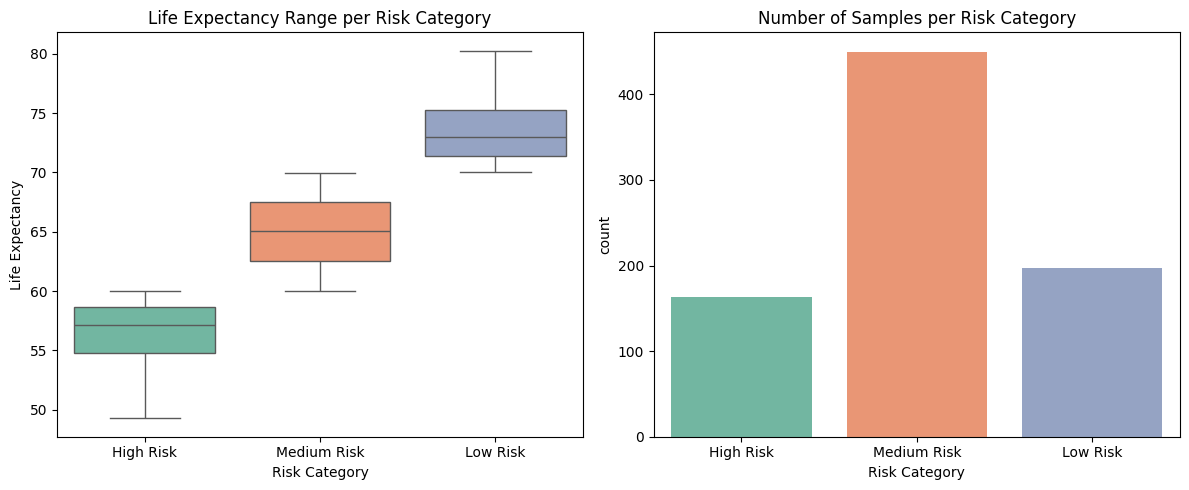

In [37]:
# Apply categorization to the whole filtered dataset for visualization
df_ml['Risk Category'] = df_ml['Life Expectancy'].apply(categorize_risk)

plt.figure(figsize=(12, 5))

# Subplot 1: Distribution of Life Expectancy by Category
plt.subplot(1, 2, 1)
sns.boxplot(x='Risk Category', y='Life Expectancy', data=df_ml, order=['High Risk', 'Medium Risk', 'Low Risk'], palette='Set2')
plt.title('Life Expectancy Range per Risk Category')

# Subplot 2: Count of samples in each category
plt.subplot(1, 2, 2)
sns.countplot(x='Risk Category', data=df_ml, order=['High Risk', 'Medium Risk', 'Low Risk'], palette='Set2')
plt.title('Number of Samples per Risk Category')

plt.tight_layout()
plt.show()

## Streamlit Web Application for Data Exploration

To create a Streamlit web application, you'll need to install the `streamlit` library first. Then, save the following Python code to a file named `app.py` and run it from your terminal using `streamlit run app.py`.

2026-05-07 18:18:56.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 18:18:56.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

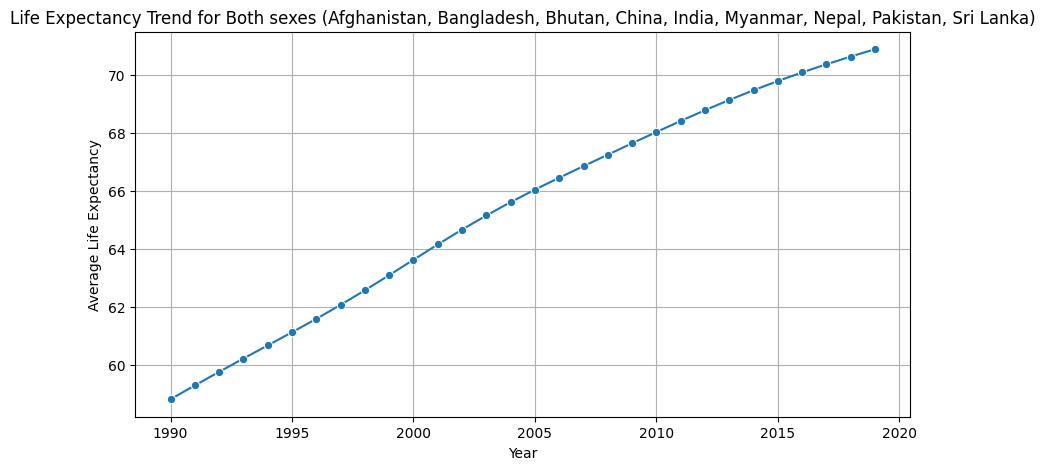

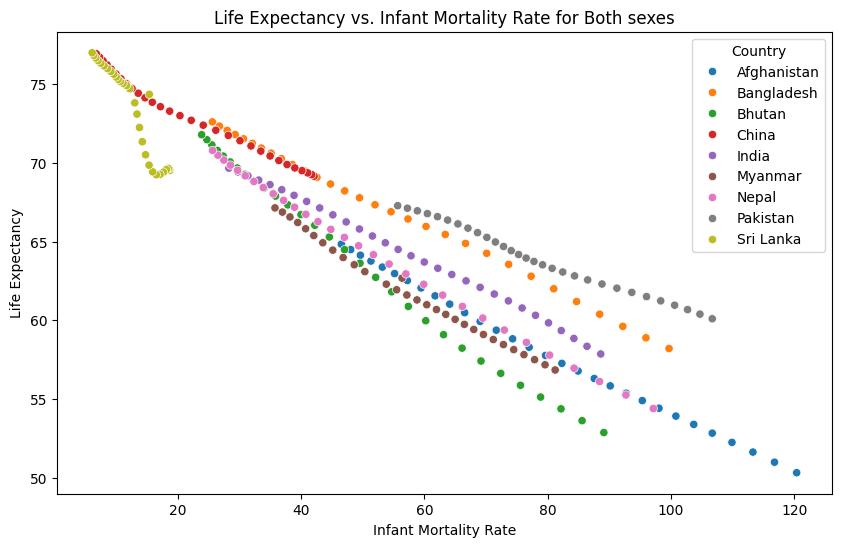

In [38]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming filtered_df is already defined and preprocessed in your Colab notebook
# If you run this as a standalone script, you'll need to load the data here:
# df = pd.read_csv('UnifiedDataset.csv')
# # Apply the same preprocessing steps as in your notebook:
# # num_cols = df.select_dtypes(include=['float64','int64']).columns
# # df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
# # df.drop_duplicates(inplace=True)
# # countries = ['India','Pakistan','Bangladesh','Nepal','Bhutan','Sri Lanka','China','Afghanistan','Myanmar']
# # filtered_df = df[df['Country'].isin(countries)]

# --- Streamlit App Layout ---
st.set_page_config(layout="wide", page_title="Life Expectancy Dashboard")

st.title("Life Expectancy Dashboard (South Asia & Neighbors)")

st.markdown("Explore life expectancy and related factors across selected countries.")

# --- Sidebar for Filters ---
st.sidebar.header("Data Filters")

# Country Multi-select
selected_countries = st.sidebar.multiselect(
    "Select Countries",
    options=filtered_df['Country'].unique(),
    default=filtered_df['Country'].unique()
)

# Year Slider
min_year, max_year = int(filtered_df['Year'].min()), int(filtered_df['Year'].max())
year_range = st.sidebar.slider(
    "Select Year Range",
    min_value=min_year,
    max_value=max_year,
    value=(min_year, max_year)
)

# Gender Selectbox
selected_gender = st.sidebar.selectbox(
    "Select Gender",
    options=['Both sexes', 'Female', 'Male'],
    index=0 # Default to 'Both sexes'
)

# Apply filters
filtered_data = filtered_df[
    (filtered_df['Country'].isin(selected_countries)) &
    (filtered_df['Year'].between(year_range[0], year_range[1])) &
    (filtered_df['Gender'] == selected_gender)
]

st.subheader("Filtered Data")
st.write(f"Displaying data for {len(filtered_data)} rows.")
st.dataframe(filtered_data)

# --- Main Panel Content ---

st.subheader("Key Metrics (Filtered Data)")
col1, col2, col3 = st.columns(3)

with col1:
    avg_le = filtered_data['Life Expectancy'].mean()
    st.metric(label="Average Life Expectancy", value=f"{avg_le:.2f} years")

with col2:
    avg_imr = filtered_data['Infant Mortality Rate'].mean()
    st.metric(label="Average Infant Mortality Rate", value=f"{avg_imr:.2f}")

with col3:
    avg_umr = filtered_data['Under 5 Mortality Rate'].mean()
    st.metric(label="Average Under 5 Mortality Rate", value=f"{avg_umr:.2f}")


st.subheader("Life Expectancy Trends Over Years")
if not filtered_data.empty:
    le_trend = filtered_data.groupby('Year')['Life Expectancy'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(x='Year', y='Life Expectancy', data=le_trend, marker='o', ax=ax)
    ax.set_title(f'Life Expectancy Trend for {selected_gender} ({', '.join(selected_countries)})')
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Life Expectancy')
    ax.grid(True)
    st.pyplot(fig)
else:
    st.warning("No data to display for the selected filters and gender.")


st.subheader("Life Expectancy vs. Infant Mortality Rate")
if not filtered_data.empty:
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x='Infant Mortality Rate', y='Life Expectancy', hue='Country', data=filtered_data, ax=ax2)
    ax2.set_title(f'Life Expectancy vs. Infant Mortality Rate for {selected_gender}')
    ax2.set_xlabel('Infant Mortality Rate')
    ax2.set_ylabel('Life Expectancy')
    st.pyplot(fig2)
else:
    st.warning("No data to display for the selected filters and gender.")


In [39]:
import pandas as pd

# Load Dataset (assuming 'UnifiedDataset.csv' is available, e.g., uploaded previously)
df = pd.read_csv("UnifiedDataset.csv")

# Apply preprocessing steps to create 'filtered_df' locally in this cell
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df.drop_duplicates(inplace=True)

countries = ['India','Pakistan','Bangladesh','Nepal','Bhutan','Sri Lanka','China','Afghanistan','Myanmar']
filtered_df = df[df['Country'].isin(countries)]

# Save the filtered_df to a CSV file so the Streamlit app can access it
filtered_df.to_csv('filtered_data.csv', index=False)
print('filtered_data.csv saved successfully.')

filtered_data.csv saved successfully.
